In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.pipeline import Pipeline


df=pd.read_csv("3-customersatisfaction.csv")


In [2]:
df

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365
...,...,...,...
95,95,2.055072,8.686851
96,96,0.864149,2.901486
97,97,-1.586101,0.786207
98,98,1.558528,5.447475


In [3]:
df.head()

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             100 non-null    int64  
 1   Customer Satisfaction  100 non-null    float64
 2   Incentive              100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [5]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


Text(0, 0.5, 'Incentive')

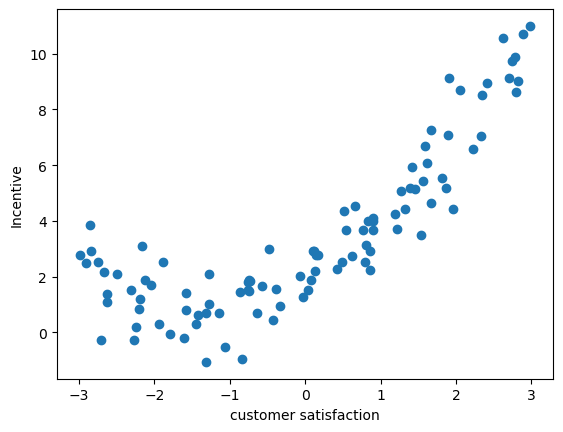

In [7]:
plt.scatter(df["Customer Satisfaction"],df["Incentive"])
plt.xlabel("customer satisfaction")
plt.ylabel("Incentive")


In [8]:
# dependent & indipendent features
X=df[["Customer Satisfaction"]]
y=df[["Incentive"]]

In [9]:
X.head()

,Customer Satisfaction
0,-1.282447
1,0.425298
2,1.953070
3,2.625838
4,-1.426333


In [10]:
y.head()

,Incentive
0,1.010513
1,2.281043
2,4.415053
3,10.563600
4,0.627365


In [11]:
#train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=15)


In [12]:
X_train

,Customer Satisfaction
99,0.512504
3,2.625838
20,-0.865714
55,-1.145369
6,2.823460
...,...
28,1.191020
0,-1.282447
5,-1.311432
12,0.490521


In [13]:
#scaler
scaler=StandardScaler()


In [14]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [15]:
regression=LinearRegression()

In [16]:
regression.fit(X_train,y_train)

LinearRegression()

In [17]:
#prediction
y_pred=regression.predict(X_test)
y_pred

array([[ 4.65663741],
       [ 3.71913877],
       [ 1.64121789],
       [ 6.29646523],
       [ 3.46766736],
       [ 5.7580845 ],
       [ 4.692485  ],
       [ 3.61616231],
       [ 5.62448003],
       [ 0.13472702],
       [ 4.47909659],
       [ 4.8130839 ],
       [ 1.58319087],
       [ 0.30515983],
       [ 5.27634309],
       [ 0.41711005],
       [-0.7385295 ],
       [-0.32653914],
       [ 3.55906887],
       [ 1.19798631]])

In [18]:
score=r2_score(y_test,y_pred)
score

0.2705652535622246

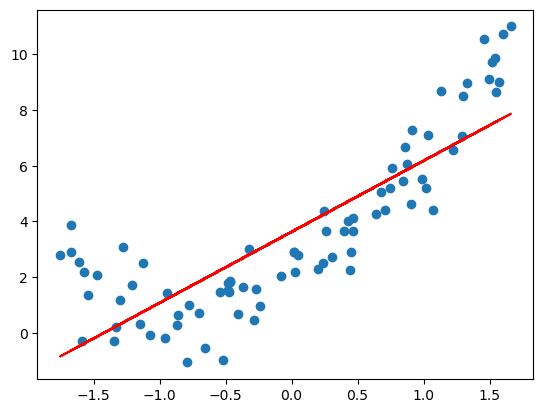

In [19]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color="r")
plt.show()

In [ ]:
#buradaki r2 skor bizim için çok düşük peki bizim bunu daha iyi bir hale getirmek için ne yapmamız lazım yani 1 e yaklaştırmak için 
#başka bir regresyon modeli denememiz lazım şimdi de polinom modelini deneyelim

poly=PolynomialFeatures(degree=2,include_bias=True)



In [21]:
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)


In [22]:
X_train_poly

array([[ 1.00000000e+00,  2.47633535e-01,  6.13223675e-02],
       [ 1.00000000e+00,  1.45565669e+00,  2.11893639e+00],
       [ 1.00000000e+00, -5.40182671e-01,  2.91797318e-01],
       [ 1.00000000e+00, -7.00039198e-01,  4.90054879e-01],
       [ 1.00000000e+00,  1.56862116e+00,  2.46057233e+00],
       [ 1.00000000e+00,  9.87568378e-01,  9.75291302e-01],
       [ 1.00000000e+00,  4.48640749e-01,  2.01278522e-01],
       [ 1.00000000e+00,  1.54377517e+00,  2.38324178e+00],
       [ 1.00000000e+00,  1.33219938e+00,  1.77475518e+00],
       [ 1.00000000e+00, -4.80410926e-01,  2.30794658e-01],
       [ 1.00000000e+00,  3.92892957e-01,  1.54364876e-01],
       [ 1.00000000e+00, -6.57456685e-01,  4.32249293e-01],
       [ 1.00000000e+00,  4.42663768e-01,  1.95951211e-01],
       [ 1.00000000e+00, -8.72131603e-01,  7.60613533e-01],
       [ 1.00000000e+00, -1.57257044e+00,  2.47297780e+00],
       [ 1.00000000e+00, -4.70184630e-01,  2.21073587e-01],
       [ 1.00000000e+00, -8.36083500e-02

In [23]:
regression=LinearRegression()
regression.fit(X_train_poly,y_train)

LinearRegression()

In [24]:
y_pred=regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
score

0.7685687698788557

In [25]:
regression.coef_

array([[0.        , 2.63871762, 1.54959954]])

In [26]:
regression.intercept_

array([2.07667643])

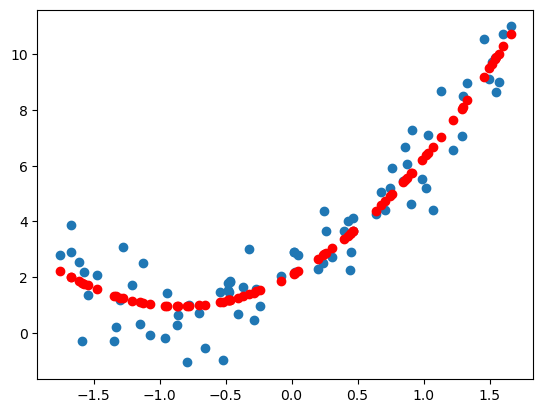

In [27]:
plt.scatter(X_train,y_train)
plt.scatter(X_train,regression.predict(X_train_poly),color="r")

In [28]:
new_df=pd.read_csv("3-newdatas.csv")
new_df.head()

,0
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397


In [29]:
new_df.rename(columns={"0":"Customer Satisfaction"},inplace=True)
new_df.head()

,Customer Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397


In [30]:
X_new=df[["Customer Satisfaction"]]
X_new

,Customer Satisfaction
0,-1.282447
1,0.425298
2,1.953070
3,2.625838
4,-1.426333
...,...
95,2.055072
96,0.864149
97,-1.586101
98,1.558528


In [31]:
scaler.fit_transform(X_new)


array([[-0.74541761],
       [ 0.25142082],
       [ 1.14320582],
       [ 1.53591163],
       [-0.82940574],
       [-0.76233635],
       [ 1.65126663],
       [ 1.37291891],
       [ 0.71002089],
       [-1.53297724],
       [ 1.63461754],
       [ 0.84939032],
       [ 0.28949243],
       [ 1.40984174],
       [ 0.04540182],
       [-0.93243424],
       [-0.44112668],
       [ 1.68544378],
       [ 0.50148195],
       [ 1.10504752],
       [-0.5021633 ],
       [-0.76845629],
       [ 0.94168121],
       [-1.57598482],
       [-0.91946171],
       [-1.23527265],
       [ 0.5246473 ],
       [-1.59788233],
       [ 0.69838517],
       [ 0.81240249],
       [ 1.62589486],
       [-1.52961611],
       [-0.2452411 ],
       [-0.22290064],
       [-0.43548366],
       [ 0.74161855],
       [ 0.08662632],
       [-0.19245176],
       [ 0.52456465],
       [-1.74381472],
       [ 0.77469897],
       [-1.32629693],
       [-1.18883599],
       [-1.55639826],
       [ 1.36574094],
       [-1

In [32]:
X_new_poly=poly.transform(X_new)

c:\Users\parsk\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


In [34]:
y_new=regression.predict(X_new_poly)
y_pred=regression.predict(X_new_poly)

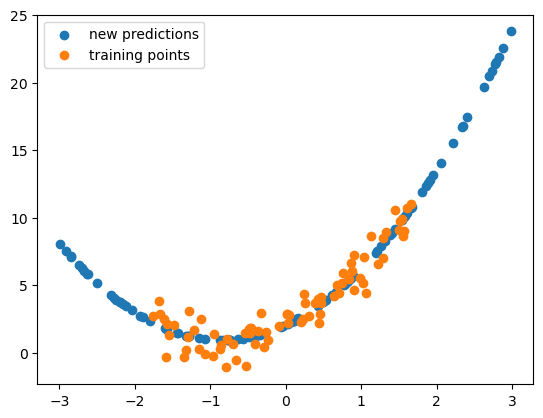

In [43]:
plt.scatter(X_new,y_new,label="new predictions")
plt.scatter(X_train,y_train,label="training points")
plt.legend()
plt.show()


In [61]:
# Pipeline ne işe yarar: aynı anda 8 9 tane degree için kullandığımız olay
# tamamen işimizi kolaylaştırmak için oluşturulmuştur
def poly_regression(degree):
    poly_features=PolynomialFeatures(degree=degree)
    lin_reg=LinearRegression()
    scaler=StandardScaler()
    pipeline=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
        ]
    )
    pipeline.fit(X_train,y_train)
    score=pipeline.score(X_test,y_test)
    print(score)

    

In [62]:
for i in [1,2,3,4,5,6,7,8,9,10]:
    poly_regression(i)
    

0.2705652535622246
0.7685687698788557
0.7573443621401048
0.7355034443260413
0.7351244165095395
0.734359048213343
0.7347819263549453
0.7411422099998382
0.7310763879815927
0.7280578621232848
